In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("sdxl_generated_images.merged_emotions.csv")

In [5]:
df.shape

(1671, 47)

In [6]:
df.columns

Index(['img_id', 'img_amusement_sdxl', 'img_awe_sdxl', 'img_contentment_sdxl',
       'img_excitement_sdxl', 'img_anger_sdxl', 'img_disgust_sdxl',
       'img_fear_sdxl', 'img_sadness_sdxl', 'img_id_raw', 'path', 'prompt',
       'img_amusement', 'img_awe', 'img_contentment', 'img_excitement',
       'img_anger', 'img_disgust', 'img_fear', 'img_sadness', 'text_amusement',
       'text_surprise', 'text_joy', 'text_excitement', 'text_anger',
       'text_disgust', 'text_fear', 'text_sadness', 'text_admiration',
       'text_annoyance', 'text_approval', 'text_caring', 'text_confusion',
       'text_curiosity', 'text_desire', 'text_disappointment',
       'text_disapproval', 'text_embarrassment', 'text_gratitude',
       'text_grief', 'text_love', 'text_nervousness', 'text_optimism',
       'text_pride', 'text_realization', 'text_relief', 'text_remorse'],
      dtype='object')

In [7]:
df.head(5)

,img_id,img_amusement_sdxl,img_awe_sdxl,img_contentment_sdxl,img_excitement_sdxl,img_anger_sdxl,img_disgust_sdxl,img_fear_sdxl,img_sadness_sdxl,img_id_raw,...,text_embarrassment,text_gratitude,text_grief,text_love,text_nervousness,text_optimism,text_pride,text_realization,text_relief,text_remorse
0,356,0.835477,0.009756,0.093765,0.006054,0.014005,0.019527,0.015092,0.006324,img.00000356,...,0.000814,0.000293,0.000248,0.000458,0.000447,0.000500,0.000409,0.016377,0.000287,0.000254
1,17,0.236748,0.039111,0.154255,0.030298,0.150876,0.017266,0.306853,0.064593,img.00000017,...,0.000618,0.000311,0.000306,0.000370,0.000317,0.000349,0.000422,0.002061,0.000279,0.000304
2,330,0.008903,0.002493,0.000795,0.002613,0.008723,0.006857,0.963974,0.005641,img.00000330,...,0.000333,0.000242,0.000234,0.000241,0.000433,0.000310,0.000293,0.005015,0.000237,0.000227
3,37,0.506355,0.172952,0.042539,0.033110,0.082612,0.113427,0.029351,0.019653,img.00000037,...,0.000394,0.000287,0.000250,0.000359,0.000247,0.000286,0.000330,0.000703,0.000254,0.000255
4,357,0.174440,0.038951,0.068776,0.136841,0.228063,0.017604,0.125206,0.210120,img.00000357,...,0.001404,0.000355,0.000281,0.000393,0.000285,0.000382,0.000418,0.009515,0.000286,0.000284


In [9]:
gpt_img_cs = [c for c in df.columns if "_sdxl" in c]
gpt_img_cs

['img_amusement_sdxl',
 'img_awe_sdxl',
 'img_contentment_sdxl',
 'img_excitement_sdxl',
 'img_anger_sdxl',
 'img_disgust_sdxl',
 'img_fear_sdxl',
 'img_sadness_sdxl']

In [10]:
# For updated GPT-based emotions
for c in gpt_img_cs:
    tc = c.rpartition("_")[0]
    df[tc] = df[c]
    print(f"Replacing {tc} -> {c}")

Replacing img_amusement -> img_amusement_sdxl
Replacing img_awe -> img_awe_sdxl
Replacing img_contentment -> img_contentment_sdxl
Replacing img_excitement -> img_excitement_sdxl
Replacing img_anger -> img_anger_sdxl
Replacing img_disgust -> img_disgust_sdxl
Replacing img_fear -> img_fear_sdxl
Replacing img_sadness -> img_sadness_sdxl


In [11]:
dup_df = df.drop(columns=[
    "img_id",
    "img_id_raw",
] + gpt_img_cs)
img_cs = [c for c in dup_df.columns if c.startswith("img_")]
pmt_cs = [c for c in dup_df.columns if c.startswith("text_")]

In [12]:
pmt_cs

['text_amusement',
 'text_surprise',
 'text_joy',
 'text_excitement',
 'text_anger',
 'text_disgust',
 'text_fear',
 'text_sadness',
 'text_admiration',
 'text_annoyance',
 'text_approval',
 'text_caring',
 'text_confusion',
 'text_curiosity',
 'text_desire',
 'text_disappointment',
 'text_disapproval',
 'text_embarrassment',
 'text_gratitude',
 'text_grief',
 'text_love',
 'text_nervousness',
 'text_optimism',
 'text_pride',
 'text_realization',
 'text_relief',
 'text_remorse']

In [13]:
def generate_text_label(row):
    argmax = np.argmax(row[pmt_cs])
    return pmt_cs[argmax].partition("_")[-1]

def generate_image_label(row):
    argmax = np.argmax(row[img_cs])
    return img_cs[argmax].partition("_")[-1]

In [14]:
df["txt_label"] = df.apply(generate_text_label, axis=1)
df["img_label"] = df.apply(generate_image_label, axis=1)

In [15]:
df["txt_label"].value_counts()

txt_label
admiration        629
approval          476
annoyance         139
excitement        125
realization        82
fear               50
joy                47
surprise           19
amusement          17
sadness            17
optimism           14
disgust            12
love                9
anger               8
curiosity           7
disappointment      7
disapproval         5
caring              2
desire              2
gratitude           1
confusion           1
remorse             1
embarrassment       1
Name: count, dtype: int64

In [16]:
df["img_label"].value_counts()

img_label
fear           648
amusement      343
awe            216
sadness        161
excitement     103
anger           94
contentment     87
disgust         19
Name: count, dtype: int64

In [17]:
df[["img_label", "txt_label"]]

,img_label,txt_label
0,amusement,approval
1,fear,excitement
2,fear,approval
3,amusement,annoyance
4,anger,annoyance
...,...,...
1666,sadness,love
1667,fear,love
1668,excitement,admiration
1669,awe,admiration


In [18]:
tdf = df.copy()
tdf["mark"] = 1
pivot_txt = tdf[["mark","path", "txt_label"]].pivot(columns="txt_label", index="path", values="mark").fillna(0)
pivot_img = tdf[["mark","path", "img_label"]].pivot(columns="img_label", index="path", values="mark").fillna(0)

pivot_txt.columns = [c+"_txt" for c in pivot_txt.columns]
pivot_img.columns = [c+"_img" for c in pivot_img.columns]

In [19]:
joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
joined_df

,amusement_img,anger_img,awe_img,contentment_img,disgust_img,excitement_img,fear_img,sadness_img,admiration_txt,amusement_txt,...,excitement_txt,fear_txt,gratitude_txt,joy_txt,love_txt,optimism_txt,realization_txt,remorse_txt,sadness_txt,surprise_txt
path,,,,,,,,,,,,,,,,,,,,,
diffusiondb_images_2m_random_10k/1003.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/1009.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/1011.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/1014.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/102.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
diffusiondb_images_2m_random_10k/981.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
diffusiondb_images_2m_random_10k/984.png,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/989.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
corr_df = joined_df.corr()
e_cs = sorted(corr_df.columns)
rel_corr_df = corr_df.loc[[c for c in e_cs if "_img" in c]][[c for c in e_cs if "_txt" in c]]
rel_corr_df

,admiration_txt,amusement_txt,anger_txt,annoyance_txt,approval_txt,caring_txt,confusion_txt,curiosity_txt,desire_txt,disappointment_txt,...,excitement_txt,fear_txt,gratitude_txt,joy_txt,love_txt,optimism_txt,realization_txt,remorse_txt,sadness_txt,surprise_txt
amusement_img,-0.018693,-0.021993,0.007682,-0.035046,0.014094,-0.017593,-0.012436,-0.010022,0.025261,0.035859,...,0.052613,-0.010987,-0.012436,0.047967,-0.017155,-0.030459,-0.005706,-0.012436,-0.021993,0.015372
anger_img,0.024748,0.027013,-0.016934,0.020510,-0.021734,-0.008452,-0.005974,-0.015835,-0.008452,-0.015835,...,-0.029931,-0.027634,-0.005974,-0.010116,0.017520,-0.022441,0.016679,-0.005974,0.027013,-0.026183
awe_img,0.043051,-0.039062,0.024961,-0.057924,-0.013950,-0.013338,-0.009428,0.002628,-0.013338,0.002628,...,0.026051,0.026560,-0.009428,0.009975,-0.003982,0.023294,-0.021467,-0.009428,-0.039062,-0.024496
contentment_img,0.001398,0.083616,-0.016255,-0.021821,-0.028545,-0.008113,-0.005735,-0.015200,-0.008113,0.026507,...,0.015277,-0.041160,-0.005735,0.106766,0.019559,0.008012,-0.040769,-0.005735,0.029928,0.000274
disgust_img,-0.013421,-0.010872,-0.007438,0.069891,0.007349,-0.003712,-0.002624,0.080436,-0.003712,-0.006956,...,-0.030495,-0.018835,-0.002624,-0.018244,-0.007892,-0.009858,0.001767,-0.002624,-0.010872,-0.011501
excitement_img,-0.045050,0.023609,0.018273,0.057956,-0.018417,-0.008872,-0.006272,0.021903,-0.008872,-0.016623,...,0.069001,-0.030408,-0.006272,0.001549,-0.018860,0.003741,0.010892,-0.006272,0.023609,-0.027486
fear_img,0.025551,-0.007251,-0.001821,-0.021806,0.028331,0.007972,0.030746,0.005428,-0.027551,-0.051620,...,-0.053568,0.062072,0.030746,-0.090824,-0.008225,0.007693,0.012515,-0.019476,0.004988,0.007321
sadness_img,-0.044389,-0.012893,-0.022648,0.077902,0.000618,0.047355,-0.007990,-0.021179,0.047355,0.041624,...,-0.046593,-0.033540,-0.007990,0.005785,0.031392,0.014488,0.019710,0.074941,0.007317,0.041498


In [21]:
rel_corr_df.columns


Index(['admiration_txt', 'amusement_txt', 'anger_txt', 'annoyance_txt',
       'approval_txt', 'caring_txt', 'confusion_txt', 'curiosity_txt',
       'desire_txt', 'disappointment_txt', 'disapproval_txt', 'disgust_txt',
       'embarrassment_txt', 'excitement_txt', 'fear_txt', 'gratitude_txt',
       'joy_txt', 'love_txt', 'optimism_txt', 'realization_txt', 'remorse_txt',
       'sadness_txt', 'surprise_txt'],
      dtype='object')

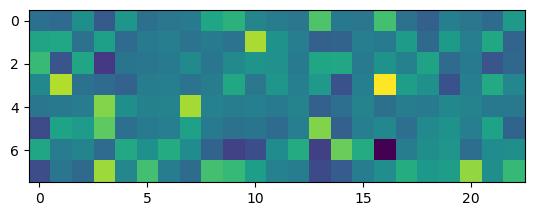

In [22]:
plt.imshow(rel_corr_df)

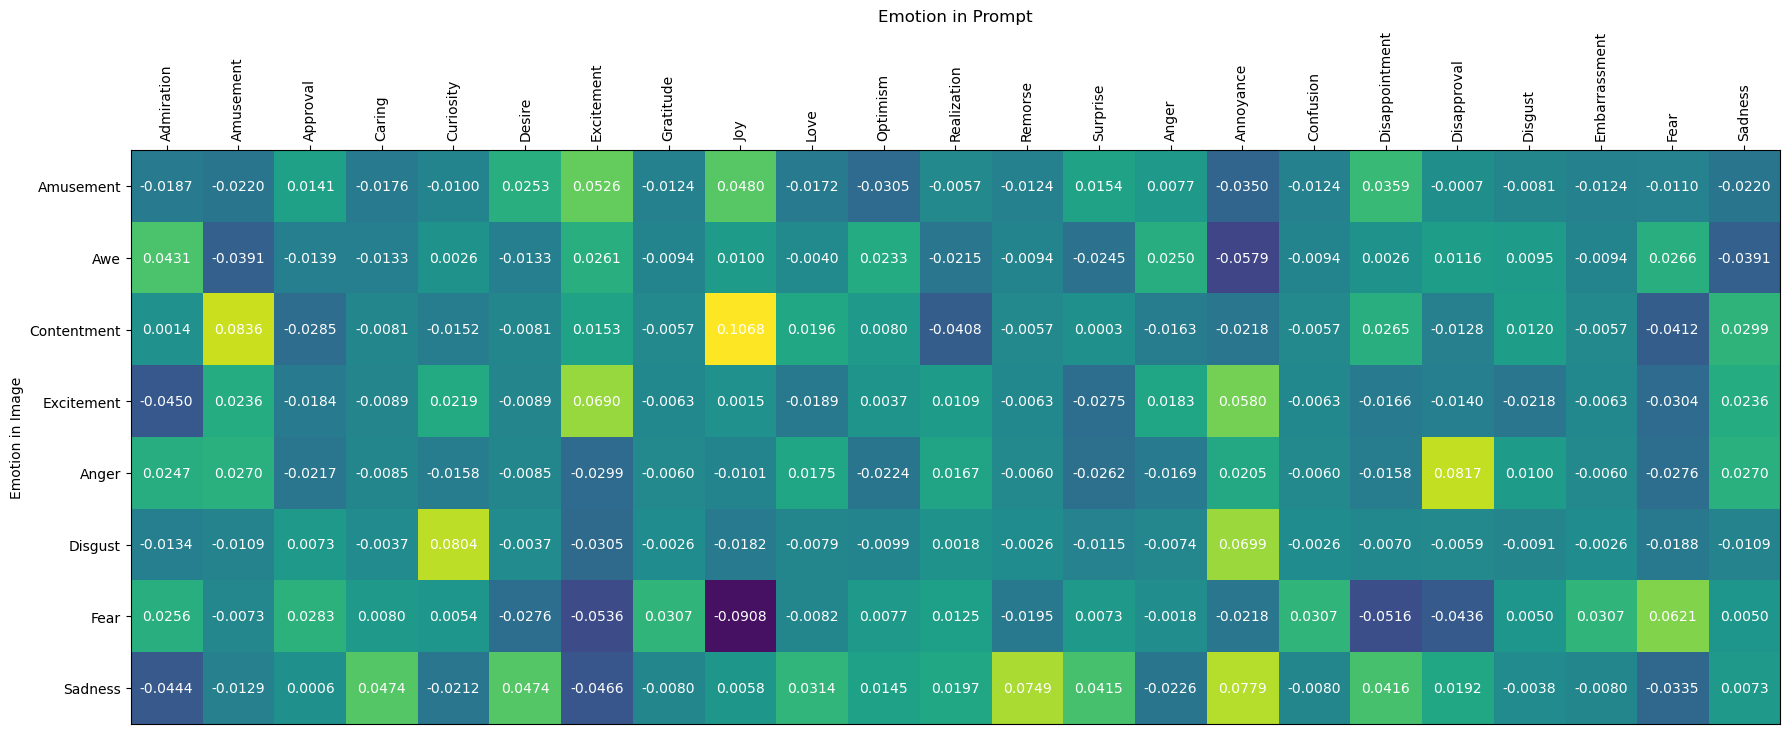

In [24]:
fig = plt.figure(figsize=(18,9))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'amusement_img',
    'awe_img',
    'contentment_img',
    'excitement_img',
    'anger_img',
    'disgust_img',
    'fear_img',
    'sadness_img'
]
col_j = [
    'admiration_txt',
    'amusement_txt',
    'approval_txt',
    'caring_txt',
    'curiosity_txt',
    'desire_txt',
    'excitement_txt',
    'gratitude_txt',
    'joy_txt',
    'love_txt',
    'optimism_txt',
    # 'pride_txt',
    'realization_txt',
    'remorse_txt',
    'surprise_txt',
    
    'anger_txt',
    'annoyance_txt',
    'confusion_txt',
    'disappointment_txt',
    'disapproval_txt',
    'disgust_txt',
    'embarrassment_txt',
    'fear_txt',
    'sadness_txt',
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("full_img_to_txt.sdxl.pdf", format="pdf")


In [25]:
# aligned_emotions = {
#     "amusement": "amusement",
#     "anger": "anger",
#     "disgust": "disgust",
#     "excitement": "excitement",
#     "fear": "fear",
#     "sadness": "sadness",
#     "joy": "contentment",
#     "love": "amusement",
#     "contentment": "contentment",
#     "awe": "awe",
#     "admiration": "awe",
# }

aligned_emotions = {
    # EmoSet
    "amusement": "joy",
    "awe": "surprise",
    "excitement": "joy",
    "contentment": "joy",
    "fear": "fear",
    "anger": "anger",
    "disgust": "disgust",
    "sadness": "sadness",

    # GoEmotions
    "annoyance": "anger",
    "disapproval": "anger",
    "nervousness": "fear",
    "disappointment": "sadness",
    "embarrassment": "sadness",
    "grief": "sadness",
    "remorse": "sadness",
    "admiration": "joy",
    "amusement": "joy",
    "approval": "joy",
    "caring": "joy",
    "desire": "joy",
    "excitement": "joy",
    "gratitude": "joy",
    "love": "joy",
    "joy": "joy",
    "optimism": "joy",
    "pride": "joy",
    "remorse": "joy",
    "curiosity": "surprise",
    "realization": "surprise",
    "surprise": "surprise",
    "confusion": "surprise",
}

e_cs = list(set(aligned_emotions.values()))
e_cs

['joy', 'disgust', 'anger', 'surprise', 'fear', 'sadness']

In [26]:
df["txt_label_aligned"] = df["txt_label"].apply(lambda s: aligned_emotions.get(s,"OTHER"))
df["img_label_aligned"] = df["img_label"].apply(lambda s: aligned_emotions.get(s,"OTHER"))


In [27]:
df["txt_label_aligned"].value_counts()

txt_label_aligned
joy         1323
anger        152
surprise     109
fear          50
sadness       25
disgust       12
Name: count, dtype: int64

In [28]:
df["img_label_aligned"].value_counts()

img_label_aligned
fear        648
joy         533
surprise    216
sadness     161
anger        94
disgust      19
Name: count, dtype: int64

In [29]:
tdf = df.copy()
tdf["mark"] = 1
pivot_txt = tdf[["mark","path", "txt_label_aligned"]].pivot(columns="txt_label_aligned", index="path", values="mark").fillna(0)
pivot_img = tdf[["mark","path", "img_label_aligned"]].pivot(columns="img_label_aligned", index="path", values="mark").fillna(0)

In [30]:
joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
joined_df

,anger_img,disgust_img,fear_img,joy_img,sadness_img,surprise_img,anger_txt,disgust_txt,fear_txt,joy_txt,sadness_txt,surprise_txt
path,,,,,,,,,,,,
diffusiondb_images_2m_random_10k/1003.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/1009.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/1011.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/1014.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/102.png,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
diffusiondb_images_2m_random_10k/981.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
diffusiondb_images_2m_random_10k/984.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/989.png,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [31]:
corr_df = joined_df.corr()
rel_corr_df = corr_df.loc[[c+"_img" for c in e_cs]][[c+"_txt" for c in e_cs]]
rel_corr_df

,joy_txt,disgust_txt,anger_txt,surprise_txt,fear_txt,sadness_txt
joy_img,0.034789,-0.012586,-0.011090,-0.019592,-0.044831,0.021426
disgust_img,-0.042300,-0.009121,0.064219,0.017386,-0.018835,-0.013217
anger_img,-0.015503,0.009996,0.031156,-0.001385,-0.027634,0.012701
surprise_img,0.048251,0.009482,-0.047443,-0.029544,0.026560,-0.032791
fear_img,-0.012245,0.005040,-0.029661,0.018556,0.062072,-0.017147
sadness_img,-0.062285,-0.003752,0.073033,0.028730,-0.033540,0.026585


In [32]:
rel_corr_df.index

Index(['joy_img', 'disgust_img', 'anger_img', 'surprise_img', 'fear_img',
       'sadness_img'],
      dtype='object')

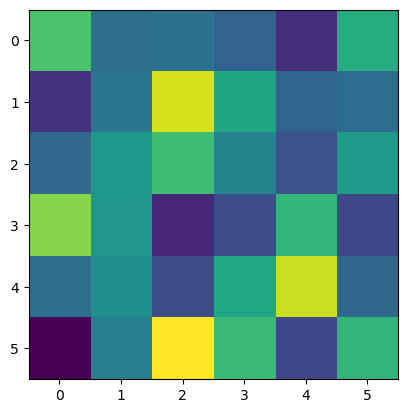

In [33]:
plt.imshow(rel_corr_df)

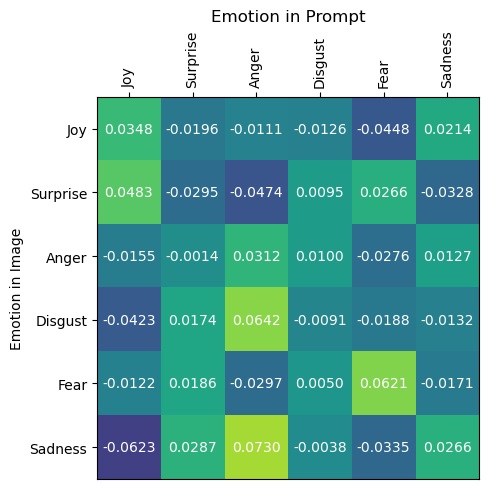

In [34]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'joy_img',
    'surprise_img',
    'anger_img',
    'disgust_img', 
    'fear_img', 
    'sadness_img',   
]
col_j = [
    'joy_txt',
    'surprise_txt',
    'anger_txt',
    'disgust_txt', 
    'fear_txt', 
    'sadness_txt',   
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("ekman_img_to_txt.sdxl.pdf", format="pdf")



In [35]:
rel_corr_df.max().max()

0.07303302935373014

In [36]:
np.mean([rel_corr_df.loc[row_i[i]][col_j[i]] for i in range(6)])

np.float64(0.01932287735394765)

In [37]:
print(classification_report(df["txt_label_aligned"], df["img_label_aligned"]))

              precision    recall  f1-score   support

       anger       0.13      0.08      0.10       152
     disgust       0.00      0.00      0.00        12
        fear       0.04      0.56      0.08        50
         joy       0.81      0.33      0.47      1323
     sadness       0.02      0.16      0.04        25
    surprise       0.05      0.09      0.06       109

    accuracy                           0.29      1671
   macro avg       0.18      0.20      0.12      1671
weighted avg       0.66      0.29      0.39      1671



In [38]:
pos_neg_groups = {
    "anger": "NEGATIVE",
    "disgust": "NEGATIVE",
    "fear": "NEGATIVE",
    "sadness": "NEGATIVE",
    "surprise": "AMBIGUOUS",
    "joy": "POSITIVE",
}
inv_pos_neg_groups = {}
for k,v in pos_neg_groups.items():
    inv_pos_neg_groups[v] = inv_pos_neg_groups.get(v,[]) + [k]

In [39]:
df["txt_label_group"] = df["txt_label_aligned"].apply(lambda s: pos_neg_groups.get(s,"OTHER"))
df["img_label_group"] = df["img_label_aligned"].apply(lambda s: pos_neg_groups.get(s,"OTHER"))


In [40]:
df["txt_label_group"].value_counts()

txt_label_group
POSITIVE     1323
NEGATIVE      239
AMBIGUOUS     109
Name: count, dtype: int64

In [41]:
df["img_label_group"].value_counts()

img_label_group
NEGATIVE     922
POSITIVE     533
AMBIGUOUS    216
Name: count, dtype: int64

In [42]:
tdf = df.copy()
tdf["mark"] = 1

In [43]:
pivot_txt = tdf[["mark","path", "txt_label_group"]].pivot(columns="txt_label_group", index="path", values="mark").fillna(0)
pivot_img = tdf[["mark","path", "img_label_group"]].pivot(columns="img_label_group", index="path", values="mark").fillna(0)

In [44]:
highest_agg = list(set(pos_neg_groups.values()))

joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
corr_df = joined_df.corr()
rel_corr_df = corr_df.loc[[c+"_img" for c in highest_agg]][[c+"_txt" for c in highest_agg]]
rel_corr_df

,NEGATIVE_txt,AMBIGUOUS_txt,POSITIVE_txt
NEGATIVE_img,0.048560,0.038292,-0.065154
AMBIGUOUS_img,-0.035126,-0.029544,0.048251
POSITIVE_img,-0.026531,-0.019592,0.034789


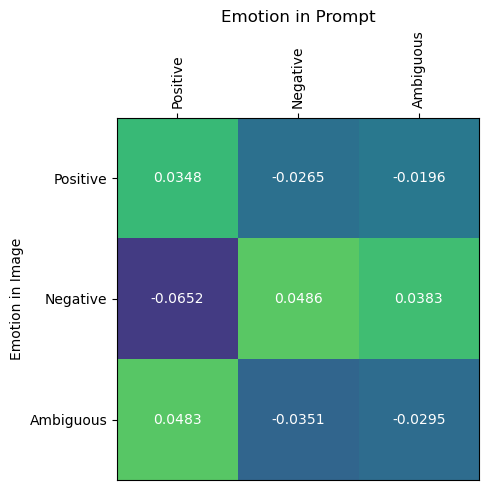

In [45]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'POSITIVE_img',
    'NEGATIVE_img',
    'AMBIGUOUS_img',
]
col_j = [
    'POSITIVE_txt',
    'NEGATIVE_txt',
    'AMBIGUOUS_txt', 
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("ekman_img_to_txt.pdf", format="pdf")

In [46]:
# True positive rate
for pl in set(aligned_emotions.values()):
    group = df[df["txt_label_aligned"] == pl]
    hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
    print(pl, hit_rate)

joy 0.327286470143613
disgust 0.0
anger 0.07894736842105263
surprise 0.09174311926605505
fear 0.56
sadness 0.16


In [47]:
# False positive rate
for pl in set(aligned_emotions.values()):
    group = df[df["img_label_aligned"] == pl]
    fps = sum(group["txt_label_aligned"] != pl)

    fpr_rate = fps / df[df["txt_label_aligned"] != pl].shape[0]
    print(pl, fpr_rate)

joy 0.28735632183908044
disgust 0.011452682338758288
anger 0.053982883475971036
surprise 0.13188220230473752
fear 0.3824799506477483
sadness 0.09538274605103281


In [48]:
# False negative rate
for pl in set(aligned_emotions.values()):
    group = df[df["txt_label_aligned"] == pl]
    miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
    print(pl, miss_rate)

joy 0.672713529856387
disgust 1.0
anger 0.9210526315789473
surprise 0.908256880733945
fear 0.44
sadness 0.84


In [49]:
for group in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
    print(group)
    local_df = df[df["txt_label_group"] == group]
    ma_tprs = []
    
    for pl in inv_pos_neg_groups[group]:
        group = df[df["txt_label_aligned"] == pl]
        hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
        print("\t", pl, hit_rate)
        ma_tprs.append(hit_rate)

    print(np.mean(ma_tprs), np.std(ma_tprs))

NEGATIVE
	 anger 0.07894736842105263
	 disgust 0.0
	 fear 0.56
	 sadness 0.16
0.19973684210526318 0.21555362592860627
AMBIGUOUS
	 surprise 0.09174311926605505
0.09174311926605505 0.0
POSITIVE
	 joy 0.327286470143613
0.327286470143613 0.0


In [50]:
for group in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
    print(group)
    local_df = df[df["txt_label_group"] == group]
    ma_fprs = []
    
    for pl in inv_pos_neg_groups[group]:
        group = df[df["txt_label_aligned"] == pl]
        miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
        print("\t", pl, miss_rate)
        ma_fprs.append(miss_rate)

    print(np.mean(ma_fprs), np.std(ma_fprs))

NEGATIVE
	 anger 0.9210526315789473
	 disgust 1.0
	 fear 0.44
	 sadness 0.84
0.8002631578947368 0.21555362592860627
AMBIGUOUS
	 surprise 0.908256880733945
0.908256880733945 0.0
POSITIVE
	 joy 0.672713529856387
0.672713529856387 0.0


In [51]:
# Bootstrap the sample
all_mrs = []
all_hrs = []
all_fprs = []
for i in range(1000):
    bt_df = df.sample(frac=1, replace=True)

    local_hr = {}
    local_mr = {}
    local_fpr = {}
    for pl in set(aligned_emotions.values()):
        group = bt_df[bt_df["txt_label_aligned"] == pl]
        
        hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
        local_hr[pl] = hit_rate
        
        miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
        local_mr[pl] = miss_rate

        pos_group = bt_df[bt_df["img_label_aligned"] == pl]
        fps = sum(pos_group["txt_label_aligned"] != pl)
        fp_rate = fps / bt_df[bt_df["txt_label_aligned"] != pl].shape[0]
        local_fpr[pl] = fp_rate
            
    all_hrs.append(local_hr)
    all_mrs.append(local_mr)
    all_fprs.append(local_fpr)

In [52]:
all_fprs

[{'joy': 0.3081570996978852,
  'disgust': 0.008438818565400843,
  'anger': 0.052803129074315516,
  'surprise': 0.12802547770700637,
  'fear': 0.4002470660901791,
  'sadness': 0.09135200974421437},
 {'joy': 0.34310850439882695,
  'disgust': 0.014449127031908489,
  'anger': 0.050165016501650166,
  'surprise': 0.14313099041533547,
  'fear': 0.3834355828220859,
  'sadness': 0.08034083992696288},
 {'joy': 0.24057971014492754,
  'disgust': 0.010876132930513595,
  'anger': 0.06324110671936758,
  'surprise': 0.1277278562259307,
  'fear': 0.37446286065070594,
  'sadness': 0.10787878787878788},
 {'joy': 0.2869822485207101,
  'disgust': 0.01622596153846154,
  'anger': 0.04316546762589928,
  'surprise': 0.128783000643915,
  'fear': 0.40086473131562694,
  'sadness': 0.09927360774818401},
 {'joy': 0.20797720797720798,
  'disgust': 0.009667673716012085,
  'anger': 0.054901960784313725,
  'surprise': 0.12427559562137798,
  'fear': 0.38878619839802836,
  'sadness': 0.08338405356055995},
 {'joy': 0.3131

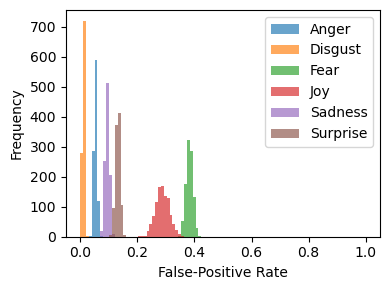

In [53]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

fpr_df = pd.DataFrame(all_fprs)
fpr_df.columns = [c.title() for c in fpr_df.columns]
sortc = sorted(fpr_df.columns)
fpr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("False-Positive Rate")

plt.tight_layout()
plt.savefig("fp_rate.sdxl.pdf", format="pdf")

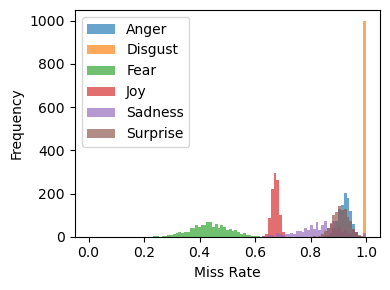

In [54]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

mr_df = pd.DataFrame(all_mrs)
mr_df.columns = [c.title() for c in mr_df.columns]
sortc = sorted(mr_df.columns)
mr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("Miss Rate")

plt.tight_layout()
plt.savefig("miss_rate.sdxl.pdf", format="pdf")

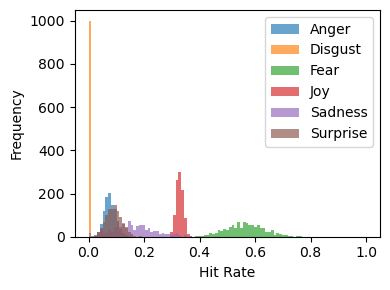

In [55]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

hr_df = pd.DataFrame(all_hrs)
hr_df.columns = [c.title() for c in hr_df.columns]
sortc = sorted(hr_df.columns)
hr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("Hit Rate")

plt.tight_layout()
plt.savefig("hit_rate.sdxl.pdf", format="pdf")

Joy: 0.3035, 0.3273, 0.3515
Disgust: 0.0000, 0.0000, 0.0000
Anger: 0.0403, 0.0777, 0.1231
Surprise: 0.0392, 0.0918, 0.1495
Fear: 0.4318, 0.5625, 0.6981
Sadness: 0.0385, 0.1623, 0.3214


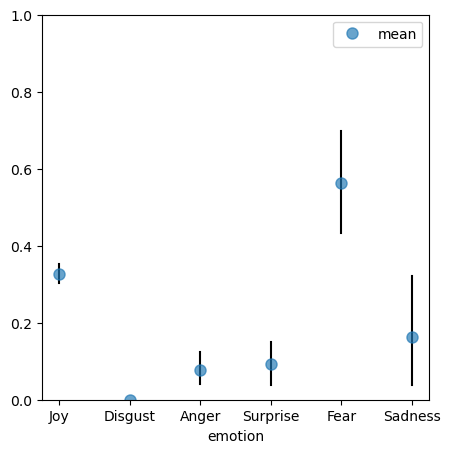

In [56]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(hr_df.shape[0] * 0.025)
    hi_i = int(hr_df.shape[0] * 0.975)
    sorted_df = hr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

Joy: 0.6490, 0.6727, 0.6966
Disgust: 1.0000, 1.0000, 1.0000
Anger: 0.8772, 0.9223, 0.9600
Surprise: 0.8515, 0.9082, 0.9608
Fear: 0.3023, 0.4375, 0.5686
Sadness: 0.6800, 0.8377, 0.9630


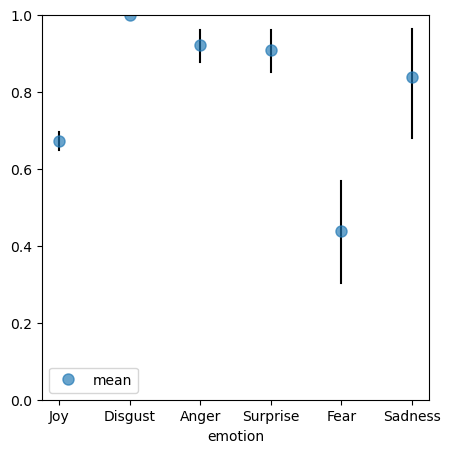

In [57]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(hr_df.shape[0] * 0.025)
    hi_i = int(hr_df.shape[0] * 0.975)
    sorted_df = mr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

Joy: 0.2429, 0.2886, 0.3365
Disgust: 0.0066, 0.0115, 0.0174
Anger: 0.0429, 0.0538, 0.0655
Surprise: 0.1152, 0.1318, 0.1477
Fear: 0.3607, 0.3825, 0.4044
Sadness: 0.0814, 0.0953, 0.1089


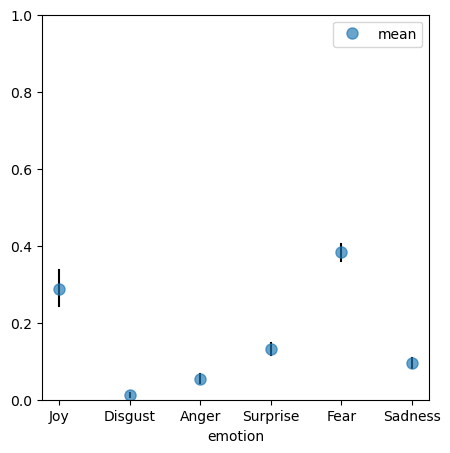

In [58]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(fpr_df.shape[0] * 0.025)
    hi_i = int(fpr_df.shape[0] * 0.975)
    sorted_df = fpr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

In [59]:
# Bootstrap the sample
all_g_mrs = []
for i in range(1000):
    bt_df = df.sample(frac=1, replace=True)

    local_mr = {}
    for group_name in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
        local_df = bt_df[bt_df["txt_label_group"] == group_name]
        ma_fprs = []
        for pl in inv_pos_neg_groups[group_name]:
            group = bt_df[bt_df["txt_label_aligned"] == pl]
            miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
            ma_fprs.append(miss_rate)
    
        local_mr[group_name] = np.mean(ma_fprs)

    all_g_mrs.append(local_mr)

Text(0.5, 0, 'Miss Rate')

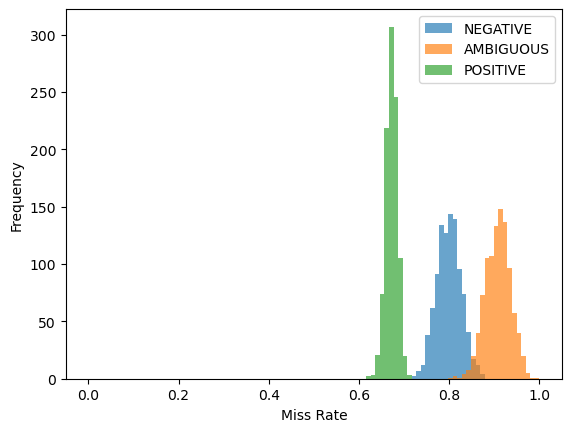

In [60]:
hr_df = pd.DataFrame(all_g_mrs)
hr_df.plot.hist(bins=np.linspace(0,1,100), alpha=0.67)
plt.xlabel("Miss Rate")